# Exploration Notebook

This notebook is used for:
- inspecting generated datasets
- validating attack injection
- identifying inconsistencies
- documenting observed issues and future improvements

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
raw_df = pd.read_csv("../data/raw/raw_logs.csv")
attack_df = pd.read_csv("../data/raw/logs_with_attacks.csv")

print("Raw dataset shape:", raw_df.shape)
print("Attack-injected dataset shape:", attack_df.shape)

Raw dataset shape: (5874, 16)
Attack-injected dataset shape: (6244, 16)


In [30]:
print("Raw logs preview:")
display(raw_df.head())

print("Attack logs preview:")
display(attack_df.head())

Raw logs preview:


,timestamp,user_id,username,department,role,privilege_level,source_ip,location,device_type,resource_accessed,action,login_success,failed_attempts,session_duration_min,is_attack,attack_type
0,2026-01-01 07:22:34,U002,donaldgarcia,HR,Staff,low,10.8.33.18,Berlin,Windows-Laptop,hr_portal,access,True,0,104,0,normal
1,2026-01-01 07:29:05,U007,lisa02,Finance,Analyst,medium,10.15.41.30,London,MacBook,security_dashboard,access,True,0,92,0,normal
2,2026-01-01 07:40:38,U007,lisa02,Finance,Analyst,medium,10.15.41.80,London,MacBook,finance_db,logout,True,0,50,0,normal
3,2026-01-01 07:54:26,U002,donaldgarcia,HR,Staff,low,10.8.33.111,Berlin,Windows-Laptop,security_dashboard,logout,True,0,37,0,normal
4,2026-01-01 08:07:53,U024,richard13,HR,Administrator,high,10.7.35.138,Toronto,MacBook,email_portal,logout,True,0,162,0,normal


Attack logs preview:


,timestamp,user_id,username,department,role,privilege_level,source_ip,location,device_type,resource_accessed,action,login_success,failed_attempts,session_duration_min,is_attack,attack_type
0,2026-01-01 00:48:34,U017,perezantonio,Engineering,Administrator,high,185.220.101.70,New York,Windows-Laptop,git_server,login,False,7,0,1,credential_stuffing
1,2026-01-01 01:18:13,U035,josephbrennan,IT,Administrator,high,185.220.101.79,Berlin,MacBook,finance_db,login,False,5,2,1,credential_stuffing
2,2026-01-01 02:10:38,U056,jenniferross,HR,Administrator,high,185.220.101.24,Toronto,MacBook,hr_portal,login,False,14,2,1,credential_stuffing
3,2026-01-01 02:14:41,U022,robinsonwilliam,Finance,Administrator,high,172.16.7.30,Toronto,Windows-Laptop,admin_console,access,True,0,9,1,lateral_movement
4,2026-01-01 02:15:41,U022,robinsonwilliam,Finance,Administrator,high,172.16.1.78,Toronto,Windows-Laptop,file_share,access,True,0,20,1,lateral_movement


## Attack Distribution
This section checks how many records belong to each attack type.

In [31]:
attack_counts = attack_df["attack_type"].value_counts()
print(attack_counts)

attack_type
normal                 5874
credential_stuffing     120
lateral_movement        100
privilege_misuse         80
abnormal_session         70
Name: count, dtype: int64


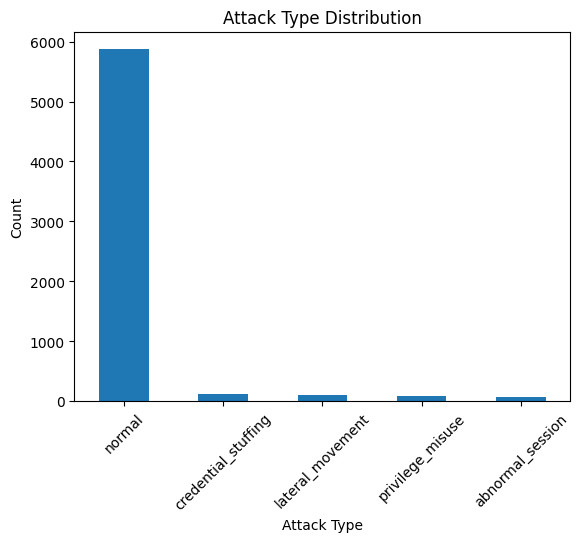

In [32]:
attack_counts.plot(kind="bar")
plt.title("Attack Type Distribution")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Login Success vs Failure
This section checks the balance between successful and failed logins.

In [33]:
login_counts = attack_df["login_success"].value_counts()
print(login_counts)

login_success
True     5686
False     558
Name: count, dtype: int64


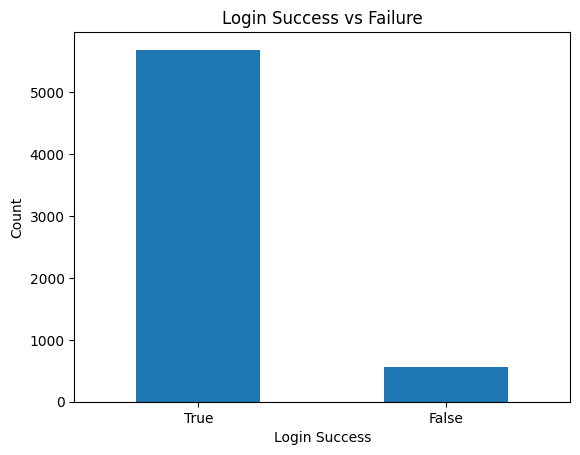

In [34]:
login_counts.plot(kind="bar")
plt.title("Login Success vs Failure")
plt.xlabel("Login Success")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## Session Duration Distribution
This section checks how session durations are distributed and whether there are unusual extremes.

In [35]:
print(attack_df["session_duration_min"].describe())

count    6244.000000
mean       86.532671
std        62.183089
min         0.000000
25%        37.000000
50%        85.000000
75%       131.000000
max       716.000000
Name: session_duration_min, dtype: float64


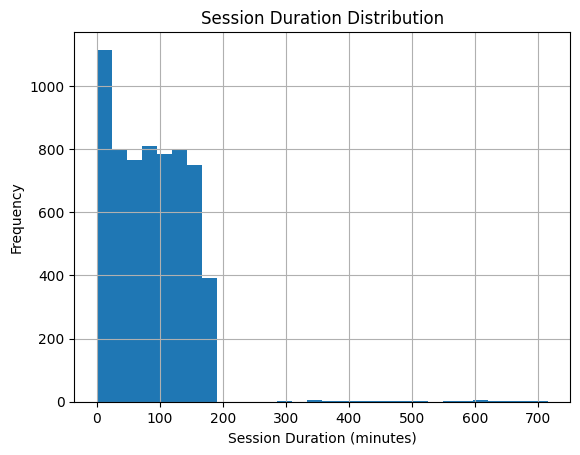

In [36]:
attack_df["session_duration_min"].hist(bins=30)
plt.title("Session Duration Distribution")
plt.xlabel("Session Duration (minutes)")
plt.ylabel("Frequency")
plt.show()

## Attack Rows Only
This section inspects only records marked as attacks.

In [37]:
attack_only = attack_df[attack_df["is_attack"] == 1]
display(attack_only.head(10))

,timestamp,user_id,username,department,role,privilege_level,source_ip,location,device_type,resource_accessed,action,login_success,failed_attempts,session_duration_min,is_attack,attack_type
0,2026-01-01 00:48:34,U017,perezantonio,Engineering,Administrator,high,185.220.101.70,New York,Windows-Laptop,git_server,login,False,7,0,1,credential_stuffing
1,2026-01-01 01:18:13,U035,josephbrennan,IT,Administrator,high,185.220.101.79,Berlin,MacBook,finance_db,login,False,5,2,1,credential_stuffing
2,2026-01-01 02:10:38,U056,jenniferross,HR,Administrator,high,185.220.101.24,Toronto,MacBook,hr_portal,login,False,14,2,1,credential_stuffing
3,2026-01-01 02:14:41,U022,robinsonwilliam,Finance,Administrator,high,172.16.7.30,Toronto,Windows-Laptop,admin_console,access,True,0,9,1,lateral_movement
4,2026-01-01 02:15:41,U022,robinsonwilliam,Finance,Administrator,high,172.16.1.78,Toronto,Windows-Laptop,file_share,access,True,0,20,1,lateral_movement
5,2026-01-01 02:16:41,U022,robinsonwilliam,Finance,Administrator,high,172.16.2.61,Toronto,Windows-Laptop,finance_db,access,True,0,22,1,lateral_movement
6,2026-01-01 02:17:41,U022,robinsonwilliam,Finance,Administrator,high,172.16.7.117,Toronto,Windows-Laptop,security_dashboard,access,True,0,16,1,lateral_movement
7,2026-01-01 02:27:10,U037,kayla51,Finance,Manager,low,185.220.101.43,Lagos,Linux-Workstation,finance_db,login,False,12,0,1,credential_stuffing
8,2026-01-01 02:37:35,U058,spenceamanda,IT,Staff,low,185.220.101.26,Berlin,Linux-Workstation,hr_portal,login,False,7,1,1,credential_stuffing
9,2026-01-01 03:08:55,U049,jeffrey28,IT,Manager,low,185.220.101.16,Lagos,Windows-Laptop,git_server,login,False,12,0,1,credential_stuffing


## User ID / Username Consistency Check
This section checks whether the same user_id is associated with multiple usernames.

In [38]:
user_username_check = attack_df.groupby("user_id")["username"].nunique()
mismatch_users = user_username_check[user_username_check > 1]

print("Number of user_id values linked to multiple usernames:", len(mismatch_users))
display(mismatch_users.head(10))

Number of user_id values linked to multiple usernames: 55


user_id
U001    6
U002    2
U003    3
U004    4
U005    5
U006    3
U007    4
U009    3
U011    4
U012    3
Name: username, dtype: int64

## Timestamp Inspection
This section checks whether attack events are clustering too heavily around certain hours.

In [39]:
attack_df["timestamp"] = pd.to_datetime(attack_df["timestamp"])
attack_df["hour"] = attack_df["timestamp"].dt.hour

hour_counts = attack_df["hour"].value_counts().sort_index()
print(hour_counts)

hour
0      26
1      36
2      48
3      40
4      14
7      98
8     228
9     441
10    647
11    684
12    652
13    630
14    654
15    632
16    568
17    408
18    258
19    103
20     18
21      1
22     20
23     38
Name: count, dtype: int64


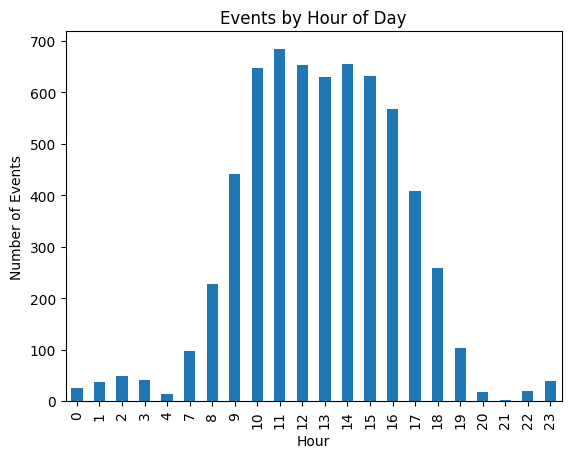

In [40]:
hour_counts.plot(kind="bar")
plt.title("Events by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Events")
plt.show()

## 🔧 Observed Issues & Improvements

### Observed Issues

1. **Session Duration Inconsistency in Logout Events**
   - Some `logout` events exhibit unusually high session durations.
   - While not incorrect, this behavior may reduce realism since logout actions are typically associated with shorter session durations.
   - Possible mismatch between `user_id` and `username` in some injected attack rows.
   - Attack timestamps may cluster heavily in off-hours, which is useful for anomaly realism but may need smoothing.
   - Some attack scenarios may still look too isolated rather than fully sequence-based.

### Planned Improvements

- Introduce constraints such that:
  - `logout` events are associated with shorter session durations.
  - `login` or `access` events better reflect realistic session timing.
- Implement action-aware session duration modeling in future dataset refinements.
- Ensure `username` always matches the selected `user_id` during attack injection.
- Add more realistic temporal sequences for attack scenarios.
- Improve internal vs external IP separation for attack events.
- Add user-level baseline features for later feature engineering.
- Review whether session durations for certain actions need tighter realism constraints.